In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [121]:
df_train = pd.read_csv("train.csv")
ph = pd.read_csv("Pistachio_Dataset.csv")

In [122]:
ph = ph.drop(["id"], axis=1)

In [123]:
ph["Class"].unique()

array(['Kirmizi_Pistachio', 'Siit_Pistachio'], dtype=object)

In [124]:
ph.loc[ph["Class"] == "Kirmizi_Pistachio", "Class"] = 0
ph.loc[ph["Class"] == "Siit_Pistachio", "Class"] = 1
ph["target"] = ph["Class"]

ph["area"] = ph["Area"]
ph["perimeter"] = ph["Perimeter"]
ph["major_axis"] = ph["Major_axis"]
ph["minor_axis"] = ph["Minor_axis"]
ph["eccentricity"] = ph["Eccentricity"]
ph["eqdiasq"] = ph["Eqdiasq"]
ph["solidity"] = ph["Solidity"]
ph["convex_area"] = ph["Covex_area"]
ph["extent"] = ph["Extent"]
ph["aspect_ratio"] = ph["Aspect_Ratio"]
ph["roundness"] = ph["Roundness"]
ph["compactness"] = ph["Compactness"]
ph["shapefactor_1"] = ph["Shapefactor_1"]
ph["shapefactor_2"] = ph["Shapefactor_2"]
ph["shapefactor_3"] = ph["Shapefactor_3"]
ph["shapefactor_4"] = ph["Shapefactor_4"]
ph = ph.drop(["Class","Area","Perimeter","Major_axis","Minor_axis","Eccentricity","Eqdiasq","Solidity","Covex_area","Extent","Aspect_Ratio","Roundness","Compactness","Shapefactor_1","Shapefactor_2","Shapefactor_3", "Shapefactor_4"],axis=1)





In [125]:
ph["target"] = pd.to_numeric(ph["target"])

In [126]:
ph["target"].unique()

array([0, 1], dtype=int64)

In [127]:
df_train.head()

,area,perimeter,major_axis,minor_axis,eccentricity,eqdiasq,solidity,convex_area,extent,aspect_ratio,roundness,compactness,shapefactor_1,shapefactor_2,shapefactor_3,shapefactor_4,target
0,75516,1731.4840,411.7352,245.7620,0.8023,310.0806,0.9148,82546,0.7169,1.6753,0.3165,0.7531,0.0055,0.0033,0.5672,0.9502,1
1,98903,1374.4370,477.2451,269.7676,0.8249,354.8622,0.9585,103181,0.7679,1.7691,0.6579,0.7436,0.0048,0.0027,0.5529,0.9781,0
2,84746,1311.1570,482.7735,235.9040,0.8725,328.4843,0.9121,92914,0.7162,2.0465,0.6195,0.6804,0.0057,0.0028,0.4630,0.9474,1
3,98184,1463.1680,434.3769,292.6472,0.7390,353.5700,0.9543,102890,0.7316,1.4843,0.5763,0.8140,0.0044,0.0030,0.6625,0.9834,0
4,94170,1267.7271,440.1109,278.4162,0.7745,346.2672,0.9643,97656,0.6836,1.5808,0.7363,0.7868,0.0047,0.0030,0.6190,0.9785,0


In [128]:
X = df_train.drop("target", axis=1)
Y = df_train["target"]

<Axes: >

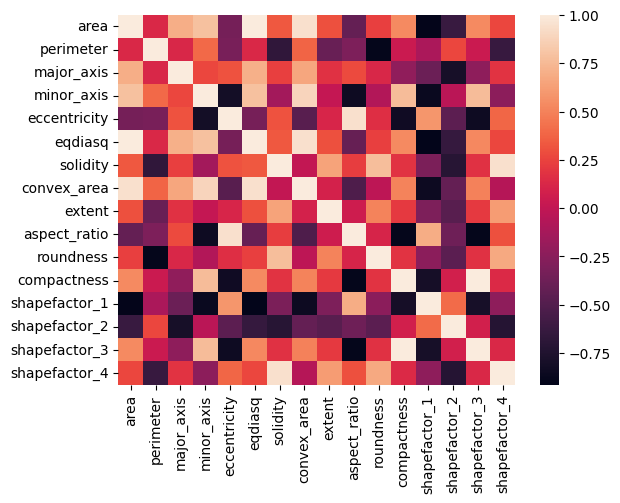

In [129]:
sns.heatmap(X.corr())

In [130]:


def get_redundant_pairs(df):
    pairs_to_drop = set()
    cols = df.columns
    for i in range(0, df.shape[1]):
        for j in range(0, i+1):
            pairs_to_drop.add((cols[i], cols[j]))
    return pairs_to_drop

def get_top_abs_correlations(df, n=5):
    au_corr = df.corr().abs().unstack()
    labels_to_drop = get_redundant_pairs(df)
    au_corr = au_corr.drop(labels=labels_to_drop).sort_values(ascending=False)
    return au_corr[0:n]

print("Top Absolute Correlations")
print(get_top_abs_correlations(X, 50))



Top Absolute Correlations
compactness    shapefactor_3    0.999074
area           eqdiasq          0.997942
solidity       shapefactor_4    0.946654
eccentricity   aspect_ratio     0.942684
area           convex_area      0.942010
eqdiasq        convex_area      0.940372
               shapefactor_1    0.913000
area           shapefactor_1    0.904832
aspect_ratio   compactness      0.896326
               shapefactor_3    0.891175
perimeter      roundness        0.891042
minor_axis     convex_area      0.887108
               shapefactor_1    0.867892
convex_area    shapefactor_1    0.852147
eccentricity   shapefactor_3    0.843566
minor_axis     aspect_ratio     0.839351
eccentricity   compactness      0.838209
minor_axis     eccentricity     0.813693
compactness    shapefactor_1    0.802317
shapefactor_1  shapefactor_3    0.794120
major_axis     shapefactor_2    0.793576
area           minor_axis       0.786976
minor_axis     eqdiasq          0.784816
solidity       roundness       

In [291]:
### Удалим колонки, где корреляция оказывается > 0.9
def correlation(dataset, threshold):
    global colnames
    colnames = []
    col_corr = set() # Set of all the names of deleted columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if (corr_matrix.iloc[i, j] >= threshold) and (corr_matrix.columns[j] not in col_corr):
                colname = corr_matrix.columns[i] # getting the name of column
                col_corr.add(colname)
                if colname in dataset.columns:
                    del dataset[colname] # deleting the column from the dataset
                    colnames.append(colname)
    


In [132]:
# from sklearn.decomposition import PCA

# pca = PCA(n_components=5)
# X_pca = pca.fit_transform(df_train.drop("target",axis=1)[colnames])
# X_pca = pd.DataFrame(X_pca, columns=['PCA_1','PCA_2','PCA_3','PCA_4','PCA_5'])
# X_pca.head()
# X = pd.concat((X, X_pca), axis=1)


sns.pairplot(
    data=X,
    corner=True,
)

In [133]:
ph.shape

(2148, 17)

In [134]:
correlation(ph, 0.90)

In [135]:
X_ph = ph.drop("target", axis=1)
Y_ph = ph["target"]

In [136]:
from sklearn.model_selection import train_test_split

X_train_ph, X_test_ph, Y_train_ph, Y_test_ph = train_test_split(X_ph, Y_ph, test_size=0.2,random_state=42)

In [137]:
# ['perimeter','major_axis','solidity','extent','roundness','shapefactor_2','shapefactor_3', 'shapefactor_4', 'eng2', 'eng3']

In [138]:
X_train_ph.shape

(1718, 11)

In [139]:
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score


cat_ph = Pipeline((("scaler", StandardScaler()),
                 ("catboost", CatBoostClassifier(learning_rate=0.3, iterations=100,verbose=0))))

cat_ph.fit(X_train_ph, Y_train_ph)
pred_test = cat_ph.predict(X_test_ph)
print(accuracy_score(Y_train_ph, cat_ph.predict(X_train_ph)))
print(accuracy_score(Y_test_ph,pred_test))

0.9377182770663562
0.8744186046511628


Best: 0.91472
from sklearn.decomposition import PCA

pca = PCA(n_components=5)
X_pca = pca.fit_transform(df_train.drop("target",axis=1)[colnames])
X_pca = pd.DataFrame(X_pca, columns=['PCA_1','PCA_2','PCA_3','PCA_4','PCA_5'])
X_pca.head()
X = pd.concat((X, X_pca), axis=1)

X["eng1"] = X["compactness"]**2+X["minor_axis"]**2
X = X.drop(["compactness"],axis=1)
X['ellipse_area'] = np.pi * X['major_axis'] * X['minor_axis'] / 4
X['area_ratio_to_ellipse'] = X['area'] / X['ellipse_area']
X = X.drop(["major_axis","minor_axis","area"],axis=1)

Corr 0.9

# Мой датасет

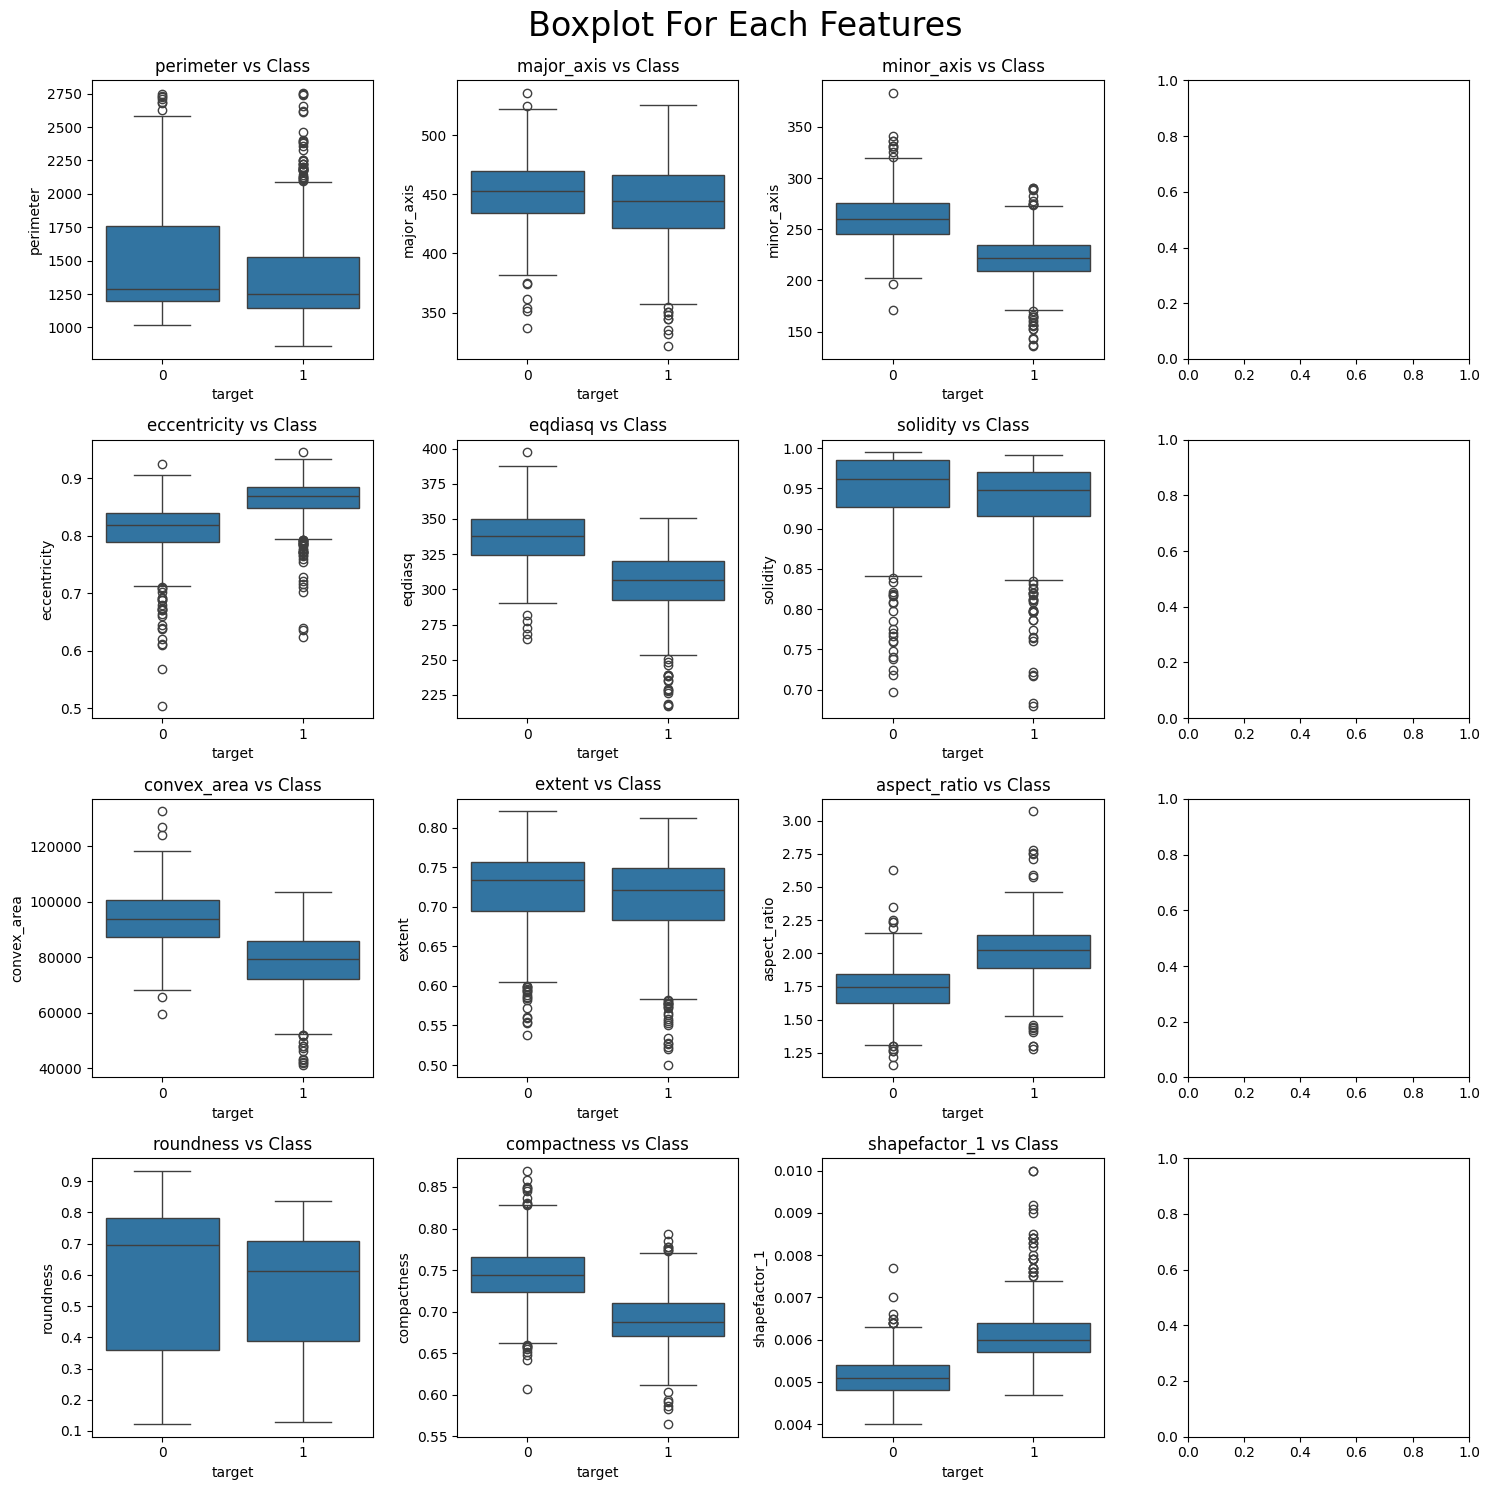

In [140]:
fig, ax = plt.subplots(4, 4, figsize=(15, 15))
idx = 1

for i in range(4):
    for j in range(3):
        column = df_train.drop(columns='target').columns[idx]
        sns.boxplot(data=df_train, y=column, x='target', ax=ax[i][j])
        ax[i][j].set_title(f'{column} vs Class')
        idx += 1

fig.suptitle('Boxplot For Each Features', fontsize=24, y=0.99)
plt.tight_layout()
plt.show()

In [141]:
df_train.shape

(1288, 17)

In [ ]:
# top_quantile = df_train['shapefactor_3'].quantile(0.975)
# low_quantile = df_train['shapefactor_3'].quantile(0.025)
# df_train = df_train[(df_train['shapefactor_3']>low_quantile)&(df_train['shapefactor_3']<top_quantile)]
# print(f"Топ 2,5% значение таргета: {top_quantile.round(2)}")
# print(f"Топ 97,5% значение таргета: {low_quantile.round(2)}")



# top_quantile = df_train['perimeter'].quantile(0.975)
# low_quantile = df_train['perimeter'].quantile(0.025)
# df_train = df_train[(df_train['perimeter']>low_quantile)&(df_train['perimeter']<top_quantile)]
# print(f"Топ 2,5% значение таргета: {top_quantile.round(2)}")
# print(f"Топ 97,5% значение таргета: {low_quantile.round(2)}")
# low_quantile = df_train['extent'].quantile(0.025)
# df_train = df_train[(df_train['extent']<top_quantile)]

Топ 2,5% значение таргета: 0.65
Топ 97,5% значение таргета: 0.41


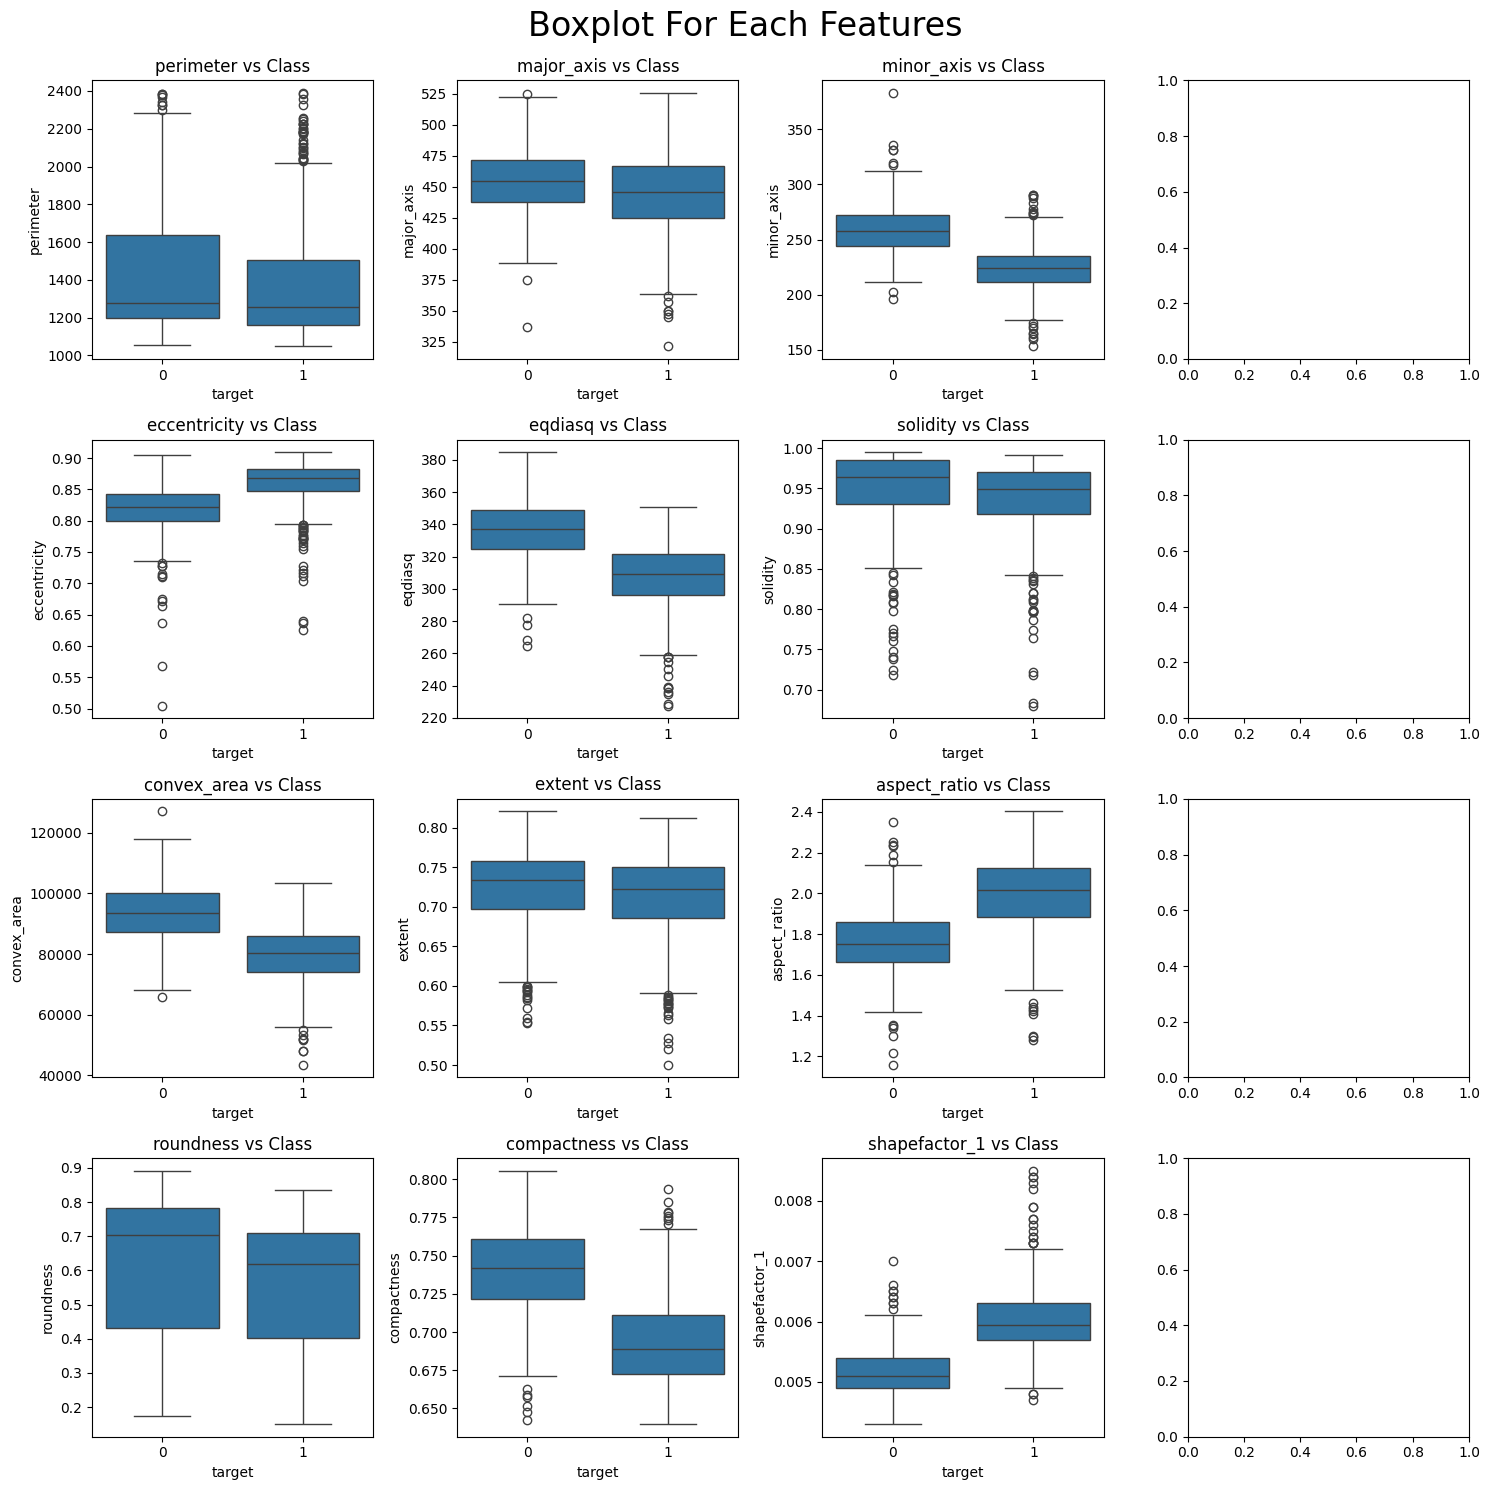

In [143]:
fig, ax = plt.subplots(4, 4, figsize=(15, 15))
idx = 1

for i in range(4):
    for j in range(3):
        column = df_train.drop(columns='target').columns[idx]
        sns.boxplot(data=df_train, y=column, x='target', ax=ax[i][j])
        ax[i][j].set_title(f'{column} vs Class')
        idx += 1

fig.suptitle('Boxplot For Each Features', fontsize=24, y=0.99)
plt.tight_layout()
plt.show()

In [144]:
df_train.shape

(1160, 17)

In [145]:
X.columns

Index(['area', 'perimeter', 'major_axis', 'minor_axis', 'eccentricity',
       'eqdiasq', 'solidity', 'convex_area', 'extent', 'aspect_ratio',
       'roundness', 'compactness', 'shapefactor_1', 'shapefactor_2',
       'shapefactor_3', 'shapefactor_4'],
      dtype='object')

<Axes: >

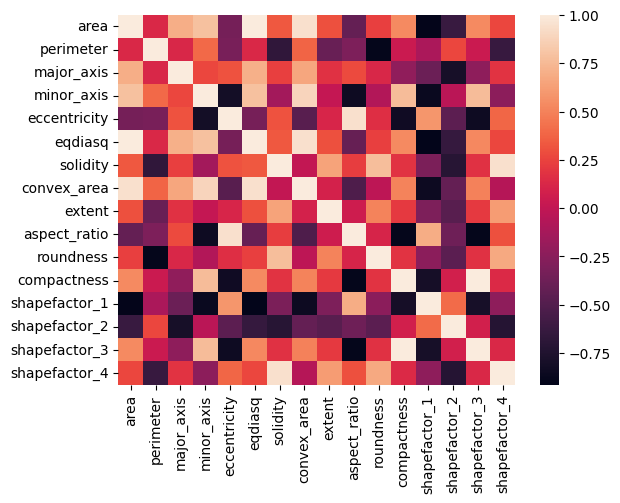

In [146]:
sns.heatmap(X.corr())

In [147]:
X = df_train.drop("target", axis=1)
Y = df_train["target"]

In [148]:
X.shape

(1160, 16)

In [149]:
Y.shape

(1160,)

In [150]:
correlation(df_train, 0.98)

In [151]:
print(colnames)

['eqdiasq', 'convex_area', 'aspect_ratio', 'shapefactor_3', 'shapefactor_4', 'eqdiasq', 'shapefactor_3']


In [152]:
Y.shape

(1160,)

In [153]:
# # # 0.906
# X["eng1"] = X["compactness"]**2+X["minor_axis"]**2
# X = X.drop(["compactness"],axis=1)
# X["eng2"] = np.sin(X["eqdiasq"])/5+np.absolute(X["eng1"])
# X["eng3"] = np.sqrt(np.log1p(X["convex_area"]) +np.arctan(X["minor_axis"])/np.absolute(np.sin(X["shapefactor_4"])))
# X["eng4"] = np.sqrt(np.log1p(X["roundness"]) +np.arctan(np.log(X["area"]))/np.absolute(X["perimeter"]))

# X = X.drop(["major_axis", "eqdiasq", "roundness","aspect_ratio", "area","perimeter","eccentricity"],axis=1)
# # 0.707 ya
# 

# from sklearn.decomposition import PCA

# pca = PCA(n_components=7)
# X_pca = pca.fit_transform(X)
# X_pca = pd.DataFrame(X_pca, columns=['PCA_1', 'PCA_2','PCA_3', 'PCA_4','PCA_5', 'PCA_6','PCA_7'], index=X.index)
# X_pca.head()
# X = pd.concat((X, X_pca), axis=1)
# df_train["eng1"] = df_train["convex_area"] / df_train["area"]
df_train["convdef"] = (np.cos(df_train["aspect_ratio"]) - np.cos(df_train["shapefactor_4"]))/np.log(df_train["convex_area"])**1.5

# X = X.drop(["convex_area","area"],axis=1)


In [154]:
from sklearn.model_selection import train_test_split, cross_validate

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2,random_state=42)

In [155]:
ls = list(X_train.columns)

In [156]:
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score

for lr in [0.01,0.015,0.1,0.2,0.3,0.31,0.39,0.4,0.41,0.42,0.5,0.6,0.7,0.8,0.9,1]:
    break
    cat = Pipeline((("scaler", StandardScaler()),
                    ("catboost", CatBoostClassifier(learning_rate=lr, iterations=100,verbose=0))))
    cross = cross_validate(cat, X_train, Y_train)
    print("cross:",np.mean(cross["test_score"]))
    cat.fit(X_train, Y_train)
    pred_test = cat.predict(X_test)
    # print(accuracy_score(Y_train, cat.predict(X_train)))
    print("val", accuracy_score(Y_test,pred_test), "lr =",lr)

In [157]:
# from lightautoml.automl.presets.tabular_presets import TabularAutoML
# from lightautoml.tasks import Task

# automl = TabularAutoML(task = Task(name = 'binary', metric = 'accuracy'))
# oof_preds = automl.fit_predict(df_train, roles = {'target': 'target'}, verbose=1).data

In [158]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score


pipe = Pipeline((("scaler", StandardScaler()),
                 ("catboost", RandomForestClassifier(150, max_depth=10))))
cross = cross_validate(pipe, X_train, Y_train)
print("cross:",np.mean(cross["test_score"]))
pipe.fit(X_train, Y_train)
pred_test = pipe.predict(X_test)
print(accuracy_score(Y_test,pred_test))

cross: 0.8437779715199071
0.896551724137931


In [159]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score


pipe = Pipeline((("scaler", StandardScaler()),
                 ("xgboost", XGBClassifier())))

pipe.fit(X_train, Y_train)
pred_test = pipe.predict(X_test)
print(accuracy_score(Y_test,pred_test))

0.8620689655172413


In [160]:
sub = pd.read_csv("test.csv")
# sub["eng1"] = sub["convex_area"] / sub["area"]
sub["convdef"] = (np.cos(sub["aspect_ratio"]) - np.cos(sub["shapefactor_4"]))/np.log(sub["convex_area"])**1.5

predictions = automl.predict(sub).data
y_pred = (predictions > 0.5).astype(int)
y_pred = pd.DataFrame(y_pred).to_csv("sub.csv", index=False)



AttributeError: 'NoneType' object has no attribute 'data'

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=7)
X_pca = pca.fit_transform(sub)
X_pca = pd.DataFrame(X_pca, columns=['PCA_1', 'PCA_2','PCA_3', 'PCA_4','PCA_5', 'PCA_6','PCA_7'])
X_pca.head()
sub = pd.concat((sub, X_pca), axis=1)
sub["eng1"] = sub["convex_area"] / sub["area"]

In [ ]:
sub.head()

,area,perimeter,major_axis,minor_axis,eccentricity,eqdiasq,solidity,convex_area,extent,aspect_ratio,...,shapefactor_4,convdef,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,eng1
0,93313,1862.7260,447.1666,278.4893,0.7824,344.6880,0.9361,99678,0.7607,1.6057,...,0.9541,-0.015705,21287.786728,-940.944121,261.182576,-20.253598,-1.659624,-0.393749,-0.079801,1.068211
1,78778,2159.5969,439.1004,240.0113,0.8374,316.7069,0.9340,84345,0.7265,1.8295,...,0.9517,-0.021888,169.451200,-419.039340,709.164093,-0.723317,3.380576,0.391232,0.021400,1.070667
2,74757,1661.6720,441.6910,225.3914,0.8600,308.5183,0.9359,79873,0.7255,1.9597,...,0.9561,-0.025204,-5838.428985,-60.405984,270.820896,6.400406,1.474932,1.024995,-0.073649,1.068435
3,88074,2199.8889,460.8836,283.3717,0.7886,334.8721,0.8709,101133,0.6922,1.6264,...,0.8586,-0.018125,18614.719138,-5687.137134,183.714886,0.916501,5.038066,-1.074771,0.001955,1.148273
4,79318,2589.4900,429.3032,279.5817,0.7589,317.7905,0.8666,91528,0.6634,1.5355,...,0.8414,-0.016344,5633.425614,-5132.600263,688.376000,-18.888771,14.189452,-2.476936,0.121437,1.153937


In [ ]:
cat = Pipeline((("scaler", StandardScaler()),
                ("catboost", CatBoostClassifier(learning_rate=0.1, iterations=100,verbose=0))))

cat.fit(X_train, Y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('catboost',
                 <catboost.core.CatBoostClassifier object at 0x00000194020B37D0>)])

In [278]:


res = cat.predict(sub[ls])
res = pd.DataFrame(res).to_csv("sub.csv", index=False)


In [292]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

In [342]:
model = nn.Sequential(
    nn.Linear(in_features=16, out_features=64, bias=True),
    nn.GELU(approximate="none"),
    nn.Dropout(p=0.01, inplace=False),
    nn.Linear(in_features=64, out_features=1024, bias=True),
    nn.Dropout(p=0.01, inplace=False),
    
    nn.BatchNorm1d(1024, eps=1e-5, momentum=0.2, affine=True, track_running_stats=True),
    nn.Dropout(p=0.01, inplace=False),

    nn.Linear(in_features=1024, out_features=2048, bias=True),
    nn.GELU(approximate="none"),
    nn.Dropout(p=0.01, inplace=False),
    nn.Linear(in_features=2048, out_features=512, bias=True),
    nn.Dropout(p=0.01, inplace=False),

    nn.Linear(in_features=512, out_features=128, bias=True),
    nn.GELU(approximate="none"),
    nn.Dropout(p=0.01, inplace=False),
    nn.Linear(in_features=128, out_features=64, bias=True),
    nn.Dropout(p=0.01, inplace=False),
    
    nn.BatchNorm1d(64, eps=1e-5, momentum=0.2, affine=True, track_running_stats=True),
    nn.Dropout(p=0.01, inplace=False),
    nn.Linear(in_features=64, out_features=2, bias=True)
)




In [163]:
model = nn.Sequential(
    nn.Linear(16,256),
    nn.BatchNorm1d(256, eps=1e-5, momentum=0.2, affine=True, track_running_stats=True),
    nn.LeakyReLU(),
    nn.Dropout(p=0.01, inplace=False),
    nn.Linear(256, 400),
    nn.BatchNorm1d(400, eps=1e-5, momentum=0.2, affine=True, track_running_stats=True),
    nn.LeakyReLU(),
    nn.Dropout(p=0.01, inplace=False),
    nn.Linear(400, 2)
)

In [420]:
df_train = pd.read_csv("train.csv")
top_quantile = df_train['shapefactor_3'].quantile(0.975)
low_quantile = df_train['shapefactor_3'].quantile(0.025)
df_train = df_train[(df_train['shapefactor_3']>low_quantile)&(df_train['shapefactor_3']<top_quantile)]
print(f"Топ 2,5% значение таргета: {top_quantile.round(2)}")
print(f"Топ 97,5% значение таргета: {low_quantile.round(2)}")



# top_quantile = df_train['perimeter'].quantile(0.975)
# low_quantile = df_train['perimeter'].quantile(0.025)
# df_train = df_train[(df_train['perimeter']>low_quantile)&(df_train['perimeter']<top_quantile)]
X = df_train.drop("target",axis=1)
Y = df_train["target"]
# correlation(X, 0.97)
print(X.shape)



scale = StandardScaler()
X = scale.fit_transform(X)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)
X_train = torch.Tensor(X_train).type(torch.FloatTensor)
Y_train = torch.Tensor(np.array(Y_train)).type(torch.LongTensor)
X_test = torch.Tensor(X_test).type(torch.FloatTensor)
Y_test = torch.Tensor(np.array(Y_test)).type(torch.LongTensor)

Топ 2,5% значение таргета: 0.65
Топ 97,5% значение таргета: 0.41
(1222, 16)


In [421]:
X_train.shape

torch.Size([977, 16])

In [423]:
class MyDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index], self.Y[index]
    
data = MyDataset(X,Y)
train_data = MyDataset(X_train,Y_train)
test_data = MyDataset(X_test,Y_test)


In [424]:

train_dataloader =  DataLoader(train_data, batch_size=32, shuffle=True)
test_dataloader =  DataLoader(test_data, batch_size=32, shuffle=True)
optim = torch.optim.AdamW(model.parameters(),lr = 0.000001)
loss_fn = torch.nn.CrossEntropyLoss()

In [425]:
@torch.inference_mode()
def evaluate(model: nn.Module, loader: DataLoader) -> tuple[float, float]:
    model.eval()

    total_loss = 0
    total = 0
    correct = 0

    for x, y in loader:
        output = model(x)

        loss = loss_fn(output, y)

        total_loss += loss.item()

        _, y_pred = torch.max(output, 1)
        total += y.size(0)
        correct += (y_pred == y).sum().item()

    total_loss /= len(loader)
    accuracy = correct / total

    return total_loss

In [426]:
for epoch in range(30):
    model.train()
    loss_all = 0
    for x, y in train_dataloader:
        # y= y.squeeze(1)
        optim.zero_grad()
        output = model(x)
        loss = loss_fn(output,y)
        loss_all += loss
        loss.backward()

        optim.step()
    # print("epoch:", epoch,loss_all)
    print("test:",evaluate(model, test_dataloader))


test: 0.14950145222246647
test: 0.15523197408765554
test: 0.14532508980482817
test: 0.1583522278815508
test: 0.1537554650567472
test: 0.1589050036855042
test: 0.1494020246900618
test: 0.15119304042309523
test: 0.14850890263915062
test: 0.16073781810700893
test: 0.15723489318042994
test: 0.14670321950688958
test: 0.15036809560842812
test: 0.14418158819898963
test: 0.15558841498568654
test: 0.15893946960568428
test: 0.15556552959606051
test: 0.1413646589498967
test: 0.17254548519849777
test: 0.1433120525907725
test: 0.15707021160051227
test: 0.15088260639458895
test: 0.15216374024748802
test: 0.14996423805132508
test: 0.1646829778328538
test: 0.15121990744955838
test: 0.16148478258401155
test: 0.1599319139495492
test: 0.14285047305747867
test: 0.16094432165846229


In [418]:
print(colnames)

['eqdiasq', 'shapefactor_3']


In [427]:
test = pd.read_csv("test.csv")
# test = test.drop(colnames, axis=1)
print(test.shape)
scale = StandardScaler()
test = scale.fit_transform(test)
res = model(torch.Tensor(test))
s = nn.functional.softmax(res, dim=1).argmax(dim=1)
pd.DataFrame(s.reshape(430,)).to_csv("neo.csv",index=False)


(430, 16)
